# CELL 0: IMPORTS

In [ ]:
# ============================================================
# CELL 0 — IMPORTS
# ============================================================

!pip install lpips

import os
import json
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import transforms

from IPython.display import display

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.1 MB/s eta 0:00:00
PyTorch: 2.11.0+cu128
CUDA: True
GPU: Tesla T4


# CELL 1: DIRECTORIES

In [ ]:
# ============================================================
# CELL 1 — DIRECTORIES
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

BASE_DIR = Path(
    "/content/drive/MyDrive/GGSS_R_victim_architecture_comparison_for_gradient_inversion_without_diffusion"
)

CHECKPOINT_DIR = BASE_DIR / "checkpoints"

RECON_DIR = BASE_DIR / "reconstruction"

RECON_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

LOG_DIR = RECON_DIR / "logs"
TRAJ_DIR = RECON_DIR / "trajectories"
FINAL_DIR = RECON_DIR / "final_reconstructions"

for d in [
    LOG_DIR,
    TRAJ_DIR,
    FINAL_DIR,
]:
    d.mkdir(
        parents=True,
        exist_ok=True,
    )

print("Checkpoint directory:")
print(CHECKPOINT_DIR)

print("\nReconstruction output:")
print(RECON_DIR)

Mounted at /content/drive
Checkpoint directory:
/content/drive/MyDrive/GGSS_R_victim_architecture_comparison_for_gradient_inversion_without_diffusion/checkpoints

Reconstruction output:
/content/drive/MyDrive/GGSS_R_victim_architecture_comparison_for_gradient_inversion_without_diffusion/reconstruction


In [ ]:
# ============================================================
# CELL 2 — TARGET IMAGE
# ============================================================

TARGET_IMAGE_PATH = Path(
    "/content/drive/MyDrive/GGSS_R_unperturbed_reproduction/data/samples/celeba_target/target_0000.png"
)

assert TARGET_IMAGE_PATH.exists(), (
    f"Target image not found:\n{TARGET_IMAGE_PATH}"
)

target_pil = Image.open(
    TARGET_IMAGE_PATH
).convert("RGB")

print("Target image:")
print(" ", TARGET_IMAGE_PATH)

print("Original size:", target_pil.size)

Target image:
  /content/drive/MyDrive/GGSS_R_unperturbed_reproduction/data/samples/celeba_target/target_0000.png
Original size: (178, 218)


# CELL 3: TARGET PREPROCESSING

In [ ]:
# ============================================================
# CELL 3 — TARGET PREPROCESSING
# ============================================================

IMAGE_SIZE = 256

preprocess = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=transforms.InterpolationMode.BILINEAR,
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5],
    ),
])

target_x = preprocess(
    target_pil
).unsqueeze(0).to(DEVICE)

assert target_x.shape == (
    1, 3, 256, 256
)

print("Target tensor:", tuple(target_x.shape))
print("dtype:", target_x.dtype)
print("device:", target_x.device)
print(
    "range:",
    float(target_x.min()),
    float(target_x.max()),
)

Target tensor: (1, 3, 256, 256)
dtype: torch.float32
device: cuda:0
range: -1.0 1.0


# CELL 4: MODEL ARCHITECTURES

In [ ]:
# ============================================================
# CELL 4 — MODEL ARCHITECTURES
# ============================================================

class SmallMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(
            3 * 256 * 256,
            128,
        )

        self.act1 = nn.Sigmoid()

        self.fc2 = nn.Linear(
            128,
            2,
        )

    def forward(self, x):
        x = x.reshape(x.size(0), -1)
        x = self.act1(self.fc1(x))
        x = self.fc2(x)
        return x


class LeNetCelebA(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                3, 12,
                kernel_size=5,
                stride=2,
                padding=2,
            ),
            nn.Sigmoid(),

            nn.Conv2d(
                12, 12,
                kernel_size=5,
                stride=2,
                padding=2,
            ),
            nn.Sigmoid(),

            nn.Conv2d(
                12, 12,
                kernel_size=5,
                stride=2,
                padding=2,
            ),
            nn.Sigmoid(),

            nn.Conv2d(
                12, 12,
                kernel_size=3,
                stride=1,
                padding=1,
            ),
            nn.Sigmoid(),
        )

        self.fc = nn.Linear(
            12 * 32 * 32,
            2,
        )

    def forward(self, x):
        x = self.features(x)
        x = x.reshape(x.size(0), -1)
        x = self.fc(x)
        return x


class GradientFriendlyCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                3, 32,
                kernel_size=3,
                stride=2,
                padding=1,
            ),
            nn.Sigmoid(),

            nn.Conv2d(
                32, 32,
                kernel_size=3,
                stride=2,
                padding=1,
            ),
            nn.Sigmoid(),

            nn.Conv2d(
                32, 64,
                kernel_size=3,
                stride=2,
                padding=1,
            ),
            nn.Sigmoid(),

            nn.Conv2d(
                64, 64,
                kernel_size=3,
                stride=2,
                padding=1,
            ),
            nn.Sigmoid(),

            nn.Conv2d(
                64, 128,
                kernel_size=3,
                stride=1,
                padding=1,
            ),
            nn.Sigmoid(),
        )

        self.fc1 = nn.Linear(
            128 * 16 * 16,
            128,
        )

        self.act = nn.Sigmoid()

        self.fc2 = nn.Linear(
            128,
            2,
        )

    def forward(self, x):
        x = self.features(x)
        x = x.reshape(x.size(0), -1)
        x = self.act(self.fc1(x))
        x = self.fc2(x)
        return x


class OverparameterizedCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                3, 64,
                kernel_size=3,
                stride=2,
                padding=1,
            ),
            nn.Sigmoid(),

            nn.Conv2d(
                64, 128,
                kernel_size=3,
                stride=2,
                padding=1,
            ),
            nn.Sigmoid(),

            nn.Conv2d(
                128, 256,
                kernel_size=3,
                stride=2,
                padding=1,
            ),
            nn.Sigmoid(),

            nn.Conv2d(
                256, 256,
                kernel_size=3,
                stride=2,
                padding=1,
            ),
            nn.Sigmoid(),

            nn.Conv2d(
                256, 256,
                kernel_size=3,
                stride=1,
                padding=1,
            ),
            nn.Sigmoid(),
        )

        self.fc1 = nn.Linear(
            256 * 16 * 16,
            512,
        )

        self.act = nn.Sigmoid()

        self.fc2 = nn.Linear(
            512,
            2,
        )

    def forward(self, x):
        x = self.features(x)
        x = x.reshape(x.size(0), -1)
        x = self.act(self.fc1(x))
        x = self.fc2(x)
        return x


MODEL_FACTORIES = {
    "mlp_small": SmallMLP,
    "lenet_sigmoid": LeNetCelebA,
    "cnn_gi": GradientFriendlyCNN,
    "cnn_overparam": OverparameterizedCNN,
}

print("Architectures loaded:")
for name in MODEL_FACTORIES:
    print(" ", name)

Architectures loaded:
  mlp_small
  lenet_sigmoid
  cnn_gi
  cnn_overparam


# CELL 5: CHECKPOINT LOADING

In [ ]:
# ============================================================
# CELL 5 — CHECKPOINT LOADING
# ============================================================

CHECKPOINTS = {}

for model_name in MODEL_FACTORIES:

    for epoch in [0, 1]:

        path = (
            CHECKPOINT_DIR /
            f"{model_name}_epoch{epoch}.pt"
        )

        if not path.exists():

            # The epoch-1 checkpoint was saved by
            # save_checkpoint(), which uses the model name.
            # Therefore try the standard name as fallback.
            if epoch == 1:
                path = (
                    CHECKPOINT_DIR /
                    f"{model_name}.pt"
                )

        assert path.exists(), (
            f"Checkpoint missing:\n{path}"
        )

        checkpoint = torch.load(
            path,
            map_location="cpu",
        )

        model = MODEL_FACTORIES[
            model_name
        ]()

        model.load_state_dict(
            checkpoint["state_dict"]
        )

        model = model.to(DEVICE)
        model.eval()

        CHECKPOINTS[
            (model_name, epoch)
        ] = model

        print(
            f"Loaded {model_name:20s} "
            f"epoch={epoch}"
        )

Loaded mlp_small            epoch=0
Loaded mlp_small            epoch=1
Loaded lenet_sigmoid        epoch=0
Loaded lenet_sigmoid        epoch=1
Loaded cnn_gi               epoch=0
Loaded cnn_gi               epoch=1
Loaded cnn_overparam        epoch=0
Loaded cnn_overparam        epoch=1


# CELL 6: FORWARD-PASS SANITY CHECK

In [ ]:
# ============================================================
# CELL 6 — FORWARD-PASS SANITY CHECK
# ============================================================

print("=" * 78)
print("TARGET FORWARD-PASS CHECK")
print("=" * 78)

criterion = nn.CrossEntropyLoss()

for (model_name, epoch), model in CHECKPOINTS.items():

    model.zero_grad(set_to_none=True)

    with torch.no_grad():
        logits = model(target_x)

    print(
        f"{model_name:20s} "
        f"epoch={epoch} "
        f"logits={logits.detach().cpu().numpy().round(5)}"
    )

TARGET FORWARD-PASS CHECK
mlp_small            epoch=0 logits=[[0.22524 0.07081]]
mlp_small            epoch=1 logits=[[ 0.91165 -0.40616]]
lenet_sigmoid        epoch=0 logits=[[ 0.05799 -0.02949]]
lenet_sigmoid        epoch=1 logits=[[-0.0283   0.01877]]
cnn_gi               epoch=0 logits=[[-0.46569 -0.55903]]
cnn_gi               epoch=1 logits=[[-0.27977 -0.24787]]
cnn_overparam        epoch=0 logits=[[-0.35663  0.02911]]
cnn_overparam        epoch=1 logits=[[-0.21943 -0.19054]]


# CELL 7: TARGET LABEL

In [ ]:
# ============================================================
# CELL 7 — TARGET LABEL
# ============================================================

TARGET_LABEL = 0

assert TARGET_LABEL in [0, 1]

target_label = torch.tensor(
    [TARGET_LABEL],
    dtype=torch.long,
    device=DEVICE,
)

print("Target label:", TARGET_LABEL)

Target label: 0


# CELL 8: TARGET GRADIENTS + LAYER NORMS

In [ ]:
# ============================================================
# CELL 8 — TARGET GRADIENTS + LAYER NORMS
# ============================================================

def get_target_gradients(model):

    model.zero_grad(
        set_to_none=True
    )

    logits = model(target_x)

    loss = criterion(
        logits,
        target_label,
    )

    grads = torch.autograd.grad(
        loss,
        tuple(model.parameters()),
        create_graph=False,
        retain_graph=False,
        allow_unused=False,
    )

    grad_dict = {}

    for (name, param), grad in zip(
        model.named_parameters(),
        grads,
    ):

        grad_dict[name] = grad.detach().clone()

    return (
        grad_dict,
        logits.detach(),
        loss.detach(),
    )


def gradient_layer_norms(
    model,
    grad_dict,
):

    rows = []

    total_sq = 0.0

    for name, grad in grad_dict.items():

        norm = float(
            torch.linalg.vector_norm(
                grad
            ).item()
        )

        total_sq += norm ** 2

        rows.append({
            "parameter": name,
            "numel": grad.numel(),
            "gradient_norm": norm,
        })

    total_norm = total_sq ** 0.5

    rows.append({
        "parameter": "__TOTAL__",
        "numel": sum(
            r["numel"]
            for r in rows
        ),
        "gradient_norm": total_norm,
    })

    return pd.DataFrame(rows)

# CELL 9: GRADIENT DIAGNOSTICS

In [ ]:
# ============================================================
# CELL 9 — GRADIENT DIAGNOSTICS
# ============================================================

TARGET_GRADIENTS = {}
TARGET_LOGITS = {}
TARGET_LOSSES = {}
TARGET_LAYER_NORMS = {}

for key, model in CHECKPOINTS.items():

    model_name, epoch = key

    grads, logits, loss = (
        get_target_gradients(model)
    )

    TARGET_GRADIENTS[key] = grads
    TARGET_LOGITS[key] = logits
    TARGET_LOSSES[key] = loss

    norm_df = gradient_layer_norms(
        model,
        grads,
    )

    TARGET_LAYER_NORMS[key] = norm_df

    print()
    print("=" * 78)
    print(
        f"{model_name} | EPOCH {epoch}"
    )
    print("=" * 78)

    print(
        "Target logits:",
        logits.cpu().numpy(),
    )

    print(
        "Target loss:",
        float(loss.item()),
    )

    display(norm_df)


mlp_small | EPOCH 0
Target logits: [[0.22524455 0.07081396]]
Target loss: 0.618910014629364


,parameter,numel,gradient_norm
0,fc1.weight,25165824,21.051929
1,fc1.bias,128,0.090462
2,fc2.weight,256,3.623862
3,fc2.bias,2,0.652616
4,__TOTAL__,25166210,21.371715



mlp_small | EPOCH 1
Target logits: [[ 0.911653   -0.40615934]]
Target loss: 0.23722028732299805


,parameter,numel,gradient_norm
0,fc1.weight,25165824,3.894806
1,fc1.bias,128,0.016736
2,fc2.weight,256,2.467933
3,fc2.bias,2,0.298657
4,__TOTAL__,25166210,4.620571



lenet_sigmoid | EPOCH 0
Target logits: [[ 0.05798613 -0.02948562]]
Target loss: 0.6503674387931824


...

,parameter,numel,gradient_norm
0,features.0.weight,864,0.000000
1,features.0.bias,32,0.000000
2,features.2.weight,9216,0.000000
3,features.2.bias,32,0.000000
4,features.4.weight,18432,0.000000
5,features.4.bias,64,0.000000
6,features.6.weight,36864,0.000000
7,features.6.bias,64,0.000000
8,features.8.weight,73728,0.000000
9,features.8.bias,128,0.000000



cnn_overparam | EPOCH 0
Target logits: [[-0.35663378  0.02911108]]
Target loss: 0.9045053720474243


,parameter,numel,gradient_norm
0,features.0.weight,1728,0.000015
1,features.0.bias,64,0.000007
2,features.2.weight,73728,0.000523
3,features.2.bias,128,0.000043
4,features.4.weight,294912,0.005686
5,features.4.bias,256,0.000329
6,features.6.weight,589824,0.056350
7,features.6.bias,256,0.002379
8,features.8.weight,589824,0.404992
9,features.8.bias,256,0.017582



cnn_overparam | EPOCH 1
Target logits: [[-0.21942908 -0.19053596]]
Target loss: 0.7076980471611023


,parameter,numel,gradient_norm
0,features.0.weight,1728,0.000000
1,features.0.bias,64,0.000000
2,features.2.weight,73728,0.000000
3,features.2.bias,128,0.000000
4,features.4.weight,294912,0.000000
5,features.4.bias,256,0.000000
6,features.6.weight,589824,0.000000
7,features.6.bias,256,0.000000
8,features.8.weight,589824,0.000000
9,features.8.bias,256,0.000000


# CELL 10: LPIPS

In [ ]:
# ============================================================
# CELL 10 — LPIPS
# ============================================================

import lpips

try:
    # Set verbose=False to prevent download hanging issues
    lpips_metric = lpips.LPIPS(net="alex", verbose=False).to(DEVICE)
    lpips_metric.eval()
    for p in lpips_metric.parameters():
        p.requires_grad_(False)
    print("LPIPS metric loaded successfully.")
except Exception as e:
    print(f"Warning: LPIPS failed to load ({e}). Falling back to dummy value.")
    lpips_metric = None


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 190MB/s]


LPIPS metric loaded successfully.


# CELL 11: METRICS

In [ ]:
# ============================================================
# CELL 11 — METRICS
# ============================================================

def flatten_gradient_dict(grad_dict):
    return torch.cat([
        g.reshape(-1)
        for g in grad_dict.values()
    ])


def gradient_metrics(
    candidate_grads,
    target_grads,
):

    g = flatten_gradient_dict(
        candidate_grads
    )

    gt = flatten_gradient_dict(
        target_grads
    )

    diff = g - gt

    absolute_distance = torch.linalg.vector_norm(
        diff
    )

    target_norm = torch.linalg.vector_norm(
        gt
    )

    relative_distance = (
        absolute_distance /
        target_norm.clamp_min(1e-12)
    )

    cosine = F.cosine_similarity(
        g.unsqueeze(0),
        gt.unsqueeze(0),
        dim=1,
    ).item()

    return (
        float(absolute_distance.item()),
        float(relative_distance.item()),
        float(cosine),
    )


def to_01(x):

    return (
        x.detach()
        .clamp(-1, 1)
        .add(1)
        .div(2)
    )


@torch.no_grad()
def pixel_mse(
    candidate,
    target,
):

    return float(
        F.mse_loss(
            to_01(candidate),
            to_01(target),
        ).item()
    )


@torch.no_grad()
def psnr_from_mse(mse):

    if mse <= 0:
        return float("inf")

    return float(
        10.0 *
        np.log10(
            1.0 / mse
        )
    )


@torch.no_grad()
def lpips_distance(
    candidate,
    target,
):

    candidate_01 = to_01(candidate)
    target_01 = to_01(target)

    return float(
        lpips_metric(
            candidate_01,
            target_01,
        ).item()
    )

# CELL 12: INVERSION CONFIGURATION

In [ ]:
# ============================================================
# CELL 12 — INVERSION CONFIGURATION
# ============================================================

NUM_STEPS = 1500

INVERSION_LR = 0.1

INVERSION_SEEDS = [
    0,
    1,
    2,
]

SAVE_EVERY = 100

print("Optimization steps:", NUM_STEPS)
print("Learning rate:", INVERSION_LR)
print("Seeds:", INVERSION_SEEDS)
print("Save trajectory every:", SAVE_EVERY)

Optimization steps: 1500
Learning rate: 0.1
Seeds: [0, 1, 2]
Save trajectory every: 100


# CELL 13: IMAGE INITIALIZATION

In [ ]:
# ============================================================
# CELL 13 — IMAGE INITIALIZATION
# ============================================================

def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def initialize_candidate(seed):

    seed_everything(seed)

    x = torch.rand(
        (1, 3, 256, 256),
        device=DEVICE,
    )

    # Convert [0,1] -> [-1,1]
    x = x * 2.0 - 1.0

    x.requires_grad_(True)

    return x

# CELL 14: SINGLE DIRECT GRADIENT INVERSION

In [ ]:
# ============================================================
# CELL 14 — SINGLE DIRECT GRADIENT INVERSION
# ============================================================

def run_single_inversion(
    model_name,
    epoch,
    seed,
):

    model = CHECKPOINTS[
        (model_name, epoch)
    ]

    target_grads = TARGET_GRADIENTS[
        (model_name, epoch)
    ]

    target_grad_flat = flatten_gradient_dict(
        target_grads
    )

    candidate = initialize_candidate(
        seed
    )

    optimizer = torch.optim.Adam(
        [candidate],
        lr=INVERSION_LR,
    )

    trajectory = []

    start_time = time.time()

    for step in range(NUM_STEPS):

        optimizer.zero_grad(
            set_to_none=True
        )


        logits = model(candidate)

        loss = criterion(
            logits,
            target_label,
        )

        candidate_grads = torch.autograd.grad(
            loss,
            tuple(model.parameters()),
            create_graph=True,
            retain_graph=True,
            allow_unused=False,
        )

        candidate_grad_flat = torch.cat([
            g.reshape(-1)
            for g in candidate_grads
        ])

        gradient_objective = F.mse_loss(
            candidate_grad_flat,
            target_grad_flat,
        )

        gradient_objective.backward()

        optimizer.step()

        # Keep candidate in valid normalized image range.
        with torch.no_grad():
            candidate.clamp_(-1.0, 1.0)

        if (
            step == 0
            or
            step == NUM_STEPS - 1
            or
            (step + 1) % SAVE_EVERY == 0
        ):

            # Reconstruct candidate gradient
            # without constructing another optimization graph.
            with torch.enable_grad():

                eval_logits = model(candidate)

                eval_loss = criterion(
                    eval_logits,
                    target_label,
                )

                eval_grads = torch.autograd.grad(
                    eval_loss,
                    tuple(model.parameters()),
                    create_graph=False,
                    retain_graph=False,
                    allow_unused=False,
                )

            eval_grad_dict = {
                name: grad.detach()
                for (name, _), grad in zip(
                    model.named_parameters(),
                    eval_grads,
                )
            }

            (
                abs_dist,
                rel_dist,
                grad_cos,
            ) = gradient_metrics(
                eval_grad_dict,
                target_grads,
            )

            mse = pixel_mse(
                candidate,
                target_x,
            )

            psnr = psnr_from_mse(
                mse
            )

            lpips_value = lpips_distance(
                candidate,
                target_x,
            )

            elapsed = (
                time.time() -
                start_time
            )

            row = {
                "model": model_name,
                "epoch": epoch,
                "seed": seed,
                "step": step,
                "objective": float(
                    gradient_objective.item()
                ),
                "gradient_distance": abs_dist,
                "relative_gradient_distance": rel_dist,
                "gradient_cosine": grad_cos,
                "mse": mse,
                "psnr": psnr,
                "lpips": lpips_value,
                "victim_loss": float(
                    eval_loss.item()
                ),
                "runtime_minutes": (
                    elapsed / 60.0
                ),
            }

            trajectory.append(row)

            print(
                f"[{model_name:16s}] "
                f"epoch={epoch} "
                f"seed={seed} "
                f"step={step:4d} "
                f"rel_grad={rel_dist:.6f} "
                f"cos={grad_cos:.6f} "
                f"MSE={mse:.6f} "
                f"PSNR={psnr:.3f} "
                f"LPIPS={lpips_value:.6f}"
            )

    total_time = (
        time.time() -
        start_time
    )

    return (
        candidate.detach(),
        pd.DataFrame(trajectory),
        total_time,
    )

# CELL 15: SAVE TRAJECTORY

In [ ]:
# ============================================================
# CELL 15 — SAVE TRAJECTORY
# ============================================================

def save_trajectory(
    trajectory,
    model_name,
    epoch,
    seed,
):

    filename = (
        f"{model_name}"
        f"_epoch{epoch}"
        f"_seed{seed}.csv"
    )

    path = (
        TRAJ_DIR /
        filename
    )

    trajectory.to_csv(
        path,
        index=False,
    )

    return path

# CELL 16: SAVE RECONSTRUCTION IMAGE

In [ ]:
# ============================================================
# CELL 16 — SAVE RECONSTRUCTION IMAGE
# ============================================================

def save_reconstruction_image(
    candidate,
    model_name,
    epoch,
    seed,
):

    image_01 = (
        to_01(candidate[0])
        .permute(1, 2, 0)
        .cpu()
        .numpy()
    )

    image_01 = (
        image_01 * 255.0
    ).round().astype(np.uint8)

    image = Image.fromarray(
        image_01
    )

    path = (
        FINAL_DIR /
        f"{model_name}"
        f"_epoch{epoch}"
        f"_seed{seed}.png"
    )

    image.save(path)

    return path

# CELL 17: SMOKE TEST

In [ ]:
# ============================================================
# CELL 17 — SMOKE TEST
# ============================================================

test_candidate, test_trajectory, test_runtime = (
    run_single_inversion(
        model_name="lenet_sigmoid",
        epoch=0,
        seed=0,
    )
)

print()
print("=" * 78)
print("SMOKE TEST COMPLETE")
print("=" * 78)

print(
    "Runtime:",
    test_runtime / 60,
    "minutes"
)

display(
    test_trajectory.tail()
)

[lenet_sigmoid   ] epoch=0 seed=0 step=   0 rel_grad=0.000553 cos=1.000000 MSE=0.152063 PSNR=8.180 LPIPS=1.279221
[lenet_sigmoid   ] epoch=0 seed=0 step=  99 rel_grad=0.000546 cos=1.000000 MSE=0.152001 PSNR=8.182 LPIPS=1.279157
[lenet_sigmoid   ] epoch=0 seed=0 step= 199 rel_grad=0.000542 cos=1.000000 MSE=0.151939 PSNR=8.183 LPIPS=1.279116
[lenet_sigmoid   ] epoch=0 seed=0 step= 299 rel_grad=0.000538 cos=1.000000 MSE=0.151878 PSNR=8.185 LPIPS=1.279079
[lenet_sigmoid   ] epoch=0 seed=0 step= 399 rel_grad=0.000533 cos=1.000000 MSE=0.151818 PSNR=8.187 LPIPS=1.279046
[lenet_sigmoid   ] epoch=0 seed=0 step= 499 rel_grad=0.000529 cos=1.000000 MSE=0.151759 PSNR=8.188 LPIPS=1.279016
[lenet_sigmoid   ] epoch=0 seed=0 step= 599 rel_grad=0.000525 cos=1.000000 MSE=0.151700 PSNR=8.190 LPIPS=1.278991
[lenet_sigmoid   ] epoch=0 seed=0 step= 699 rel_grad=0.000521 cos=1.000000 MSE=0.151642 PSNR=8.192 LPIPS=1.278964
[lenet_sigmoid   ] epoch=0 seed=0 step= 799 rel_grad=0.000517 cos=1.000000 MSE=0.151585 

,model,epoch,seed,step,objective,gradient_distance,relative_gradient_distance,gradient_cosine,mse,psnr,lpips,victim_loss,runtime_minutes
11,lenet_sigmoid,0,0,1099,1.084112e-08,0.019204,0.000505,1.0,0.151418,8.198235,1.278882,0.650385,0.098826
12,lenet_sigmoid,0,0,1199,1.067814e-08,0.019059,0.000501,1.0,0.151363,8.199795,1.278863,0.650385,0.109673
13,lenet_sigmoid,0,0,1299,1.051863e-08,0.018916,0.000497,1.0,0.151310,8.201335,1.278843,0.650384,0.119272
14,lenet_sigmoid,0,0,1399,1.036252e-08,0.018775,0.000494,1.0,0.151257,8.202855,1.278823,0.650384,0.129022
15,lenet_sigmoid,0,0,1499,1.020982e-08,0.018636,0.000490,1.0,0.151204,8.204357,1.278802,0.650384,0.139341


In [ ]:
test_csv = save_trajectory(
    test_trajectory,
    "lenet_sigmoid",
    0,
    0,
)

test_png = save_reconstruction_image(
    test_candidate,
    "lenet_sigmoid",
    0,
    0,
)

print("Trajectory:", test_csv)
print("Image:", test_png)

Trajectory: /content/drive/MyDrive/GGSS_R_victim_architecture_comparison_for_gradient_inversion_without_diffusion/reconstruction/trajectories/lenet_sigmoid_epoch0_seed0.csv
Image: /content/drive/MyDrive/GGSS_R_victim_architecture_comparison_for_gradient_inversion_without_diffusion/reconstruction/final_reconstructions/lenet_sigmoid_epoch0_seed0.png


# CELL 18: FULL ARCHITECTURE × EPOCH × SEED EXPERIMENT

In [ ]:
# ============================================================
# CELL 18 — FULL ARCHITECTURE × EPOCH × SEED EXPERIMENT
# ============================================================

ALL_RESULTS = []
FINAL_IMAGES = []

experiment_start = time.time()

for model_name in MODEL_FACTORIES:

    for epoch in [0, 1]:

        for seed in INVERSION_SEEDS:

            print()
            print("=" * 78)
            print(
                f"STARTING "
                f"{model_name} | "
                f"EPOCH {epoch} | "
                f"SEED {seed}"
            )
            print("=" * 78)

            candidate, trajectory, runtime = (
                run_single_inversion(
                    model_name=model_name,
                    epoch=epoch,
                    seed=seed,
                )
            )

            csv_path = save_trajectory(
                trajectory,
                model_name,
                epoch,
                seed,
            )

            image_path = (
                save_reconstruction_image(
                    candidate,
                    model_name,
                    epoch,
                    seed,
                )
            )

            final_row = (
                trajectory
                .iloc[-1]
                .to_dict()
            )

            final_row[
                "final_image"
            ] = str(image_path)

            final_row[
                "trajectory_csv"
            ] = str(csv_path)

            final_row[
                "total_runtime_minutes"
            ] = runtime / 60.0

            ALL_RESULTS.append(
                final_row
            )

            FINAL_IMAGES.append(
                candidate.cpu()
            )

            print()
            print(
                f"Completed in "
                f"{runtime/60:.2f} min"
            )

            # Free as much GPU memory as possible.
            del candidate
            del trajectory

            if torch.cuda.is_available():
                torch.cuda.empty_cache()


total_experiment_time = (
    time.time() -
    experiment_start
)

print()
print("=" * 78)
print("FULL EXPERIMENT COMPLETE")
print("=" * 78)

print(
    "Total runtime:",
    total_experiment_time / 60,
    "minutes"
)


STARTING mlp_small | EPOCH 0 | SEED 0
[mlp_small       ] epoch=0 seed=0 step=   0 rel_grad=1.037502 cos=0.037475 MSE=0.151278 PSNR=8.202 LPIPS=1.278734
[mlp_small       ] epoch=0 seed=0 step=  99 rel_grad=0.997671 cos=0.097213 MSE=0.148828 PSNR=8.273 LPIPS=1.276784
[mlp_small       ] epoch=0 seed=0 step= 199 rel_grad=0.997422 cos=0.098438 MSE=0.147460 PSNR=8.313 LPIPS=1.276105
[mlp_small       ] epoch=0 seed=0 step= 299 rel_grad=0.997062 cos=0.099884 MSE=0.145850 PSNR=8.361 LPIPS=1.275344
[mlp_small       ] epoch=0 seed=0 step= 399 rel_grad=0.996504 cos=0.102198 MSE=0.143883 PSNR=8.420 LPIPS=1.274433
[mlp_small       ] epoch=0 seed=0 step= 499 rel_grad=0.995570 cos=0.106969 MSE=0.141340 PSNR=8.497 LPIPS=1.273295
[mlp_small       ] epoch=0 seed=0 step= 599 rel_grad=0.993887 cos=0.117346 MSE=0.137816 PSNR=8.607 LPIPS=1.271775
[mlp_small       ] epoch=0 seed=0 step= 699 rel_grad=0.990682 cos=0.138926 MSE=0.132604 PSNR=8.774 LPIPS=1.269422
[mlp_small       ] epoch=0 seed=0 step= 799 rel_g

# CELL 19: FINAL COMPARISON

In [ ]:
# ============================================================
# CELL 19 — FINAL COMPARISON
# ============================================================

results_df = pd.DataFrame(
    ALL_RESULTS
)

results_path = (
    RECON_DIR /
    "all_final_results.csv"
)

results_df.to_csv(
    results_path,
    index=False,
)

columns = [
    "model",
    "epoch",
    "seed",
    "objective",
    "gradient_distance",
    "relative_gradient_distance",
    "gradient_cosine",
    "mse",
    "psnr",
    "lpips",
    "total_runtime_minutes",
]

display(
    results_df[
        columns
    ].sort_values(
        [
            "model",
            "epoch",
            "seed",
        ]
    )
)

print()
print(
    "Saved:",
    results_path
)

,model,epoch,seed,objective,gradient_distance,relative_gradient_distance,gradient_cosine,mse,psnr,lpips,total_runtime_minutes
12,cnn_gi,0,0,1.303115e-13,0.000752,0.000078,1.000000,0.152064,8.179739,1.279222,0.170898
13,cnn_gi,0,1,1.305789e-13,0.000752,0.000078,1.000000,0.152185,8.176279,1.266355,0.173243
14,cnn_gi,0,2,1.341325e-13,0.000762,0.000079,1.000000,0.151571,8.193840,1.268761,0.164586
15,cnn_gi,1,0,0.000000e+00,0.000000,0.000000,1.000000,0.152064,8.179739,1.279222,0.170686
16,cnn_gi,1,1,0.000000e+00,0.000000,0.000000,1.000000,0.152185,8.176279,1.266355,0.174047
17,cnn_gi,1,2,0.000000e+00,0.000000,0.000000,1.000000,0.151571,8.193840,1.268761,0.176410
18,cnn_overparam,0,0,4.964269e-14,0.001320,0.000072,1.000000,0.152064,8.179739,1.279222,0.591379
19,cnn_overparam,0,1,4.975786e-14,0.001322,0.000072,1.000000,0.152185,8.176279,1.266355,0.592668
20,cnn_overparam,0,2,4.902879e-14,0.001312,0.000071,1.000000,0.151571,8.193840,1.268761,0.593924
21,cnn_overparam,1,0,0.000000e+00,0.000000,0.000000,1.000000,0.152064,8.179739,1.279222,0.566057



Saved: /content/drive/MyDrive/GGSS_R_victim_architecture_comparison_for_gradient_inversion_without_diffusion/reconstruction/all_final_results.csv


# SAVE ALL 28 FINAL RECONSTRUCTIONS TO DRIVE

In [ ]:
# ============================================================
# SAVE ALL 28 FINAL RECONSTRUCTIONS TO DRIVE
# ============================================================

FINAL_RECON_DIR = RECON_DIR / "final_reconstructions"
FINAL_RECON_DIR.mkdir(parents=True, exist_ok=True)

saved_paths = []

idx = 0

for model_name in MODEL_FACTORIES:
    for epoch in [0, 1]:
        for seed in INVERSION_SEEDS:

            image_tensor = FINAL_IMAGES[idx]

            # image_tensor should be [3, H, W].
            # Convert from [-1, 1] to [0, 1] if necessary.
            image_tensor = image_tensor.detach().cpu()

            if image_tensor.ndim == 4:
                image_tensor = image_tensor.squeeze(0)

            image_tensor = image_tensor.clamp(-1, 1)
            image_tensor = (image_tensor + 1.0) / 2.0

            # Convert CHW -> HWC and save as PNG.
            image_np = (
                image_tensor
                .permute(1, 2, 0)
                .numpy()
            )

            image_uint8 = (
                image_np * 255.0
            ).round().astype(np.uint8)

            filename = (
                f"{model_name}"
                f"_epoch{epoch}"
                f"_seed{seed}"
                f".png"
            )

            output_path = (
                FINAL_RECON_DIR / filename
            )

            Image.fromarray(
                image_uint8
            ).save(output_path)

            saved_paths.append(output_path)

            print(
                f"[{idx+1:02d}/28] Saved: "
                f"{output_path.name}"
            )

            idx += 1


print()
print("=" * 78)
print("ALL FINAL RECONSTRUCTIONS SAVED")
print("=" * 78)
print("Count:", len(saved_paths))
print("Directory:", FINAL_RECON_DIR)

[01/28] Saved: mlp_small_epoch0_seed0.png
[02/28] Saved: mlp_small_epoch0_seed1.png
[03/28] Saved: mlp_small_epoch0_seed2.png
[04/28] Saved: mlp_small_epoch1_seed0.png
[05/28] Saved: mlp_small_epoch1_seed1.png
[06/28] Saved: mlp_small_epoch1_seed2.png
[07/28] Saved: lenet_sigmoid_epoch0_seed0.png
[08/28] Saved: lenet_sigmoid_epoch0_seed1.png
[09/28] Saved: lenet_sigmoid_epoch0_seed2.png
[10/28] Saved: lenet_sigmoid_epoch1_seed0.png
[11/28] Saved: lenet_sigmoid_epoch1_seed1.png
[12/28] Saved: lenet_sigmoid_epoch1_seed2.png
[13/28] Saved: cnn_gi_epoch0_seed0.png
[14/28] Saved: cnn_gi_epoch0_seed1.png
[15/28] Saved: cnn_gi_epoch0_seed2.png
[16/28] Saved: cnn_gi_epoch1_seed0.png
[17/28] Saved: cnn_gi_epoch1_seed1.png
[18/28] Saved: cnn_gi_epoch1_seed2.png
[19/28] Saved: cnn_overparam_epoch0_seed0.png
[20/28] Saved: cnn_overparam_epoch0_seed1.png
[21/28] Saved: cnn_overparam_epoch0_seed2.png
[22/28] Saved: cnn_overparam_epoch1_seed0.png
[23/28] Saved: cnn_overparam_epoch1_seed1.png
[24/28] 

# CELL 20: AGGREGATED RESULTS

In [ ]:
# ============================================================
# CELL 20 — AGGREGATED RESULTS
# ============================================================

aggregate = (
    results_df
    .groupby(
        ["model", "epoch"]
    )
    .agg(
        gradient_distance_mean=(
            "gradient_distance",
            "mean",
        ),
        gradient_distance_std=(
            "gradient_distance",
            "std",
        ),
        relative_gradient_distance_mean=(
            "relative_gradient_distance",
            "mean",
        ),
        gradient_cosine_mean=(
            "gradient_cosine",
            "mean",
        ),
        mse_mean=(
            "mse",
            "mean",
        ),
        mse_std=(
            "mse",
            "std",
        ),
        psnr_mean=(
            "psnr",
            "mean",
        ),
        lpips_mean=(
            "lpips",
            "mean",
        ),
    )
    .reset_index()
)

display(aggregate)

aggregate_path = (
    RECON_DIR /
    "architecture_epoch_summary.csv"
)

aggregate.to_csv(
    aggregate_path,
    index=False,
)

print(
    "Saved:",
    aggregate_path
)

,model,epoch,gradient_distance_mean,gradient_distance_std,relative_gradient_distance_mean,gradient_cosine_mean,mse_mean,mse_std,psnr_mean,lpips_mean
0,cnn_gi,0,0.000755,0.000006,0.000078,1.000000,0.151940,0.000325,8.183286,1.271446
1,cnn_gi,1,0.000000,0.000000,0.000000,1.000000,0.151940,0.000325,8.183286,1.271446
2,cnn_overparam,0,0.001318,0.000005,0.000072,1.000000,0.151940,0.000325,8.183286,1.271446
3,cnn_overparam,1,0.000000,0.000000,0.000000,1.000000,0.151940,0.000325,8.183286,1.271446
4,lenet_sigmoid,0,0.018555,0.000164,0.000488,1.000000,0.151086,0.000312,8.207778,1.270399
5,lenet_sigmoid,1,0.017957,0.000115,0.006587,0.999982,0.124778,0.000090,9.038624,1.278140
6,mlp_small,0,2.388025,0.580727,0.111738,0.993487,0.001127,0.000431,29.718123,0.118924
7,mlp_small,1,6.751613,3.721635,1.461207,0.235486,0.163973,0.021043,7.875124,1.201966


Saved: /content/drive/MyDrive/GGSS_R_victim_architecture_comparison_for_gradient_inversion_without_diffusion/reconstruction/architecture_epoch_summary.csv


# CELL 21: TRAJECTORY PLOTS

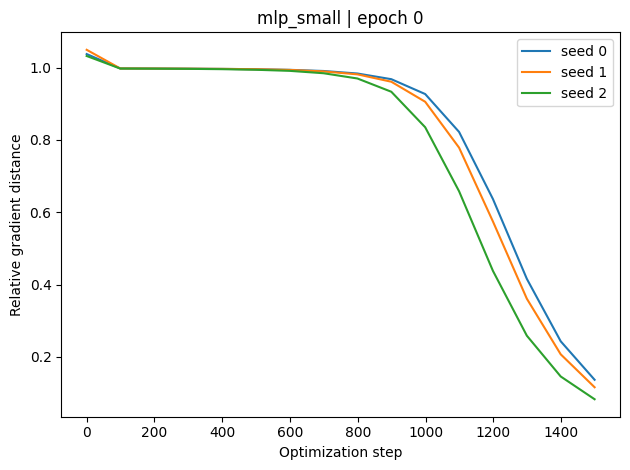

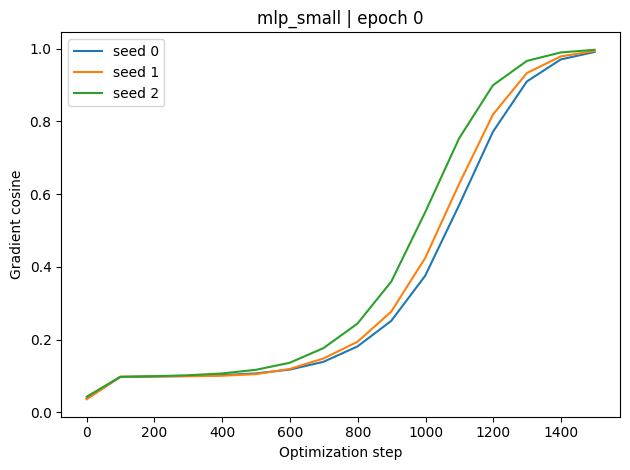

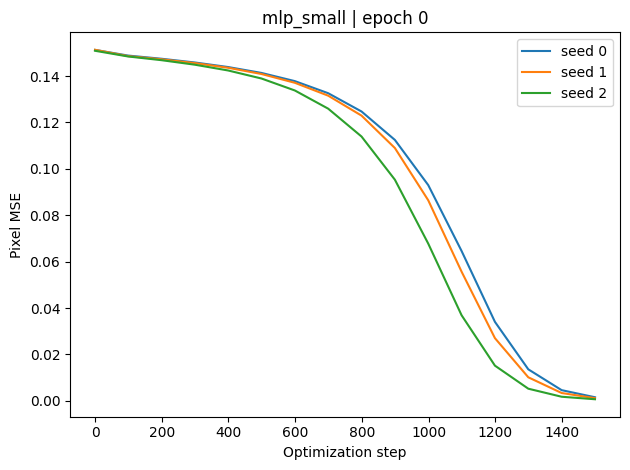

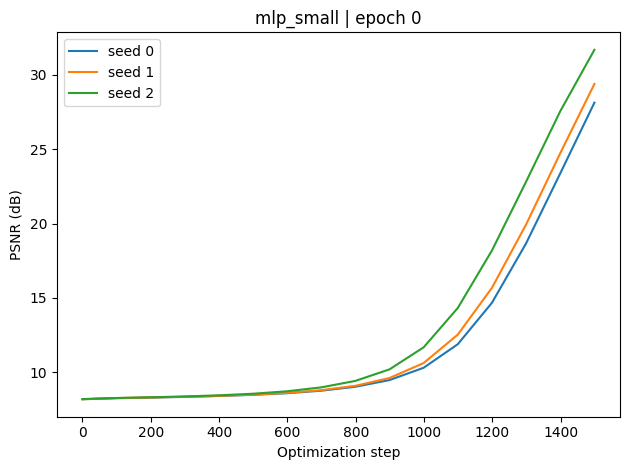

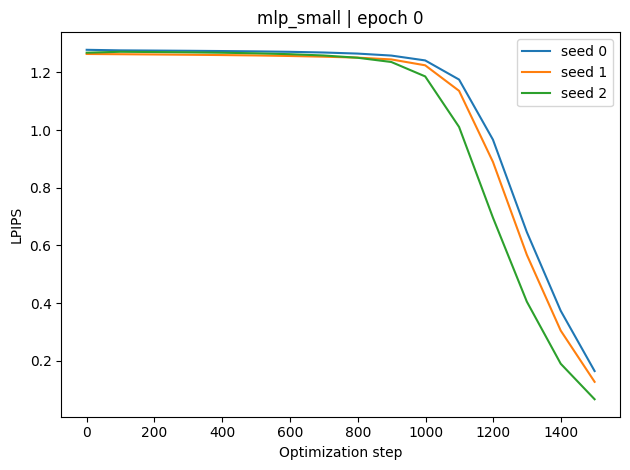

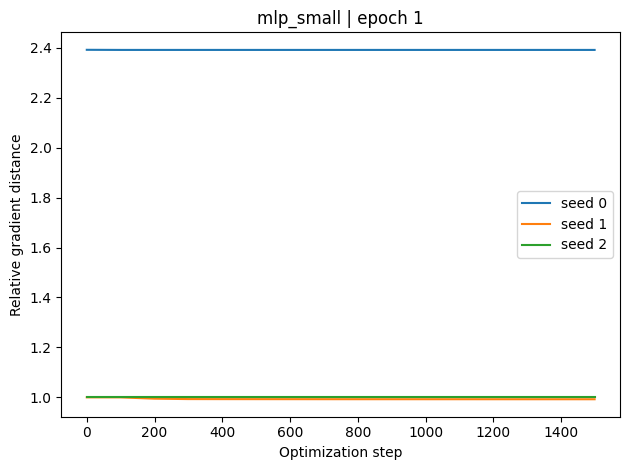

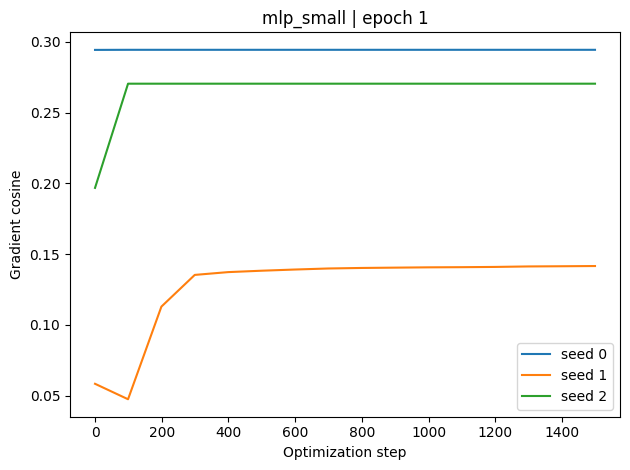

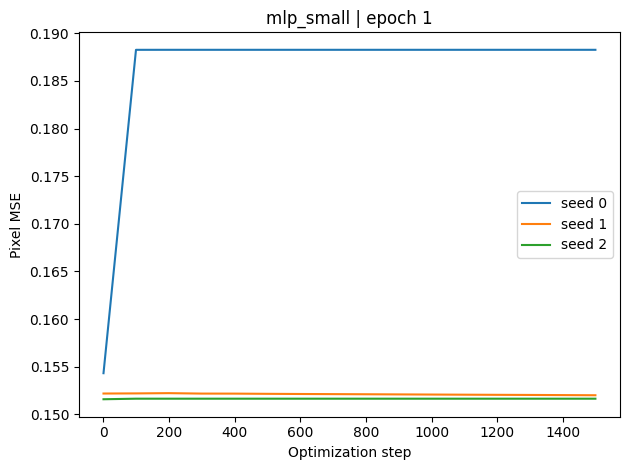

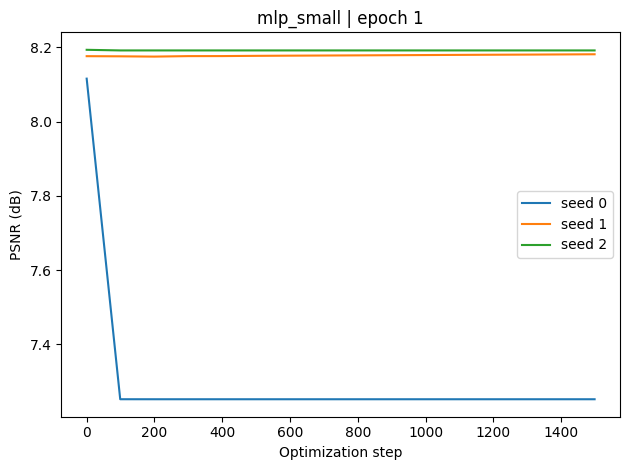

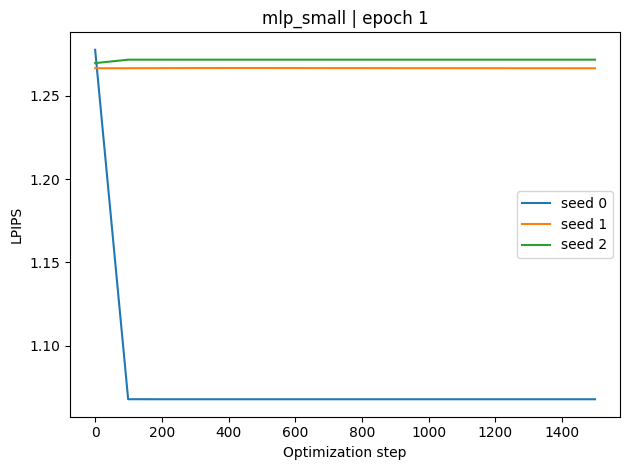

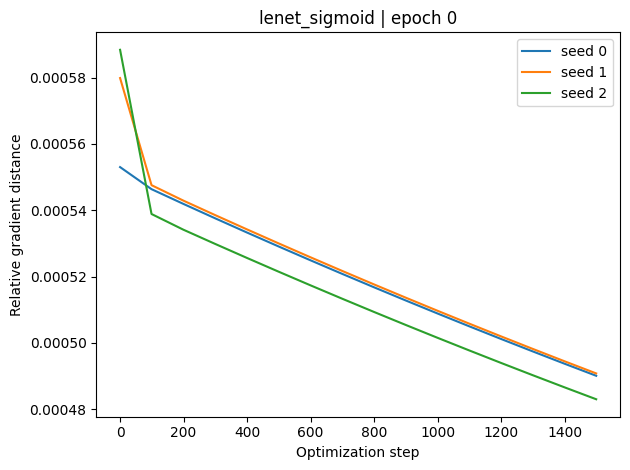

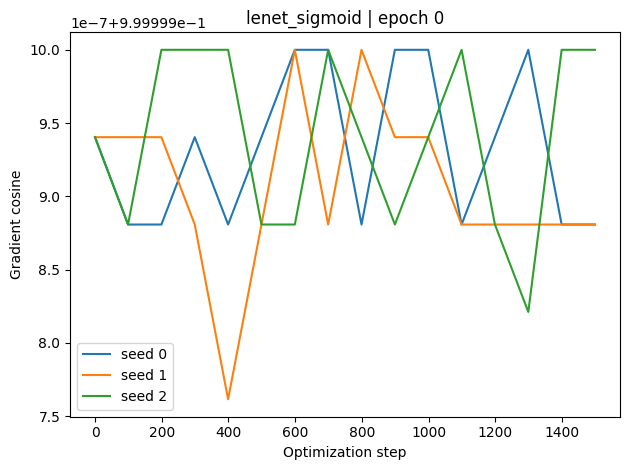

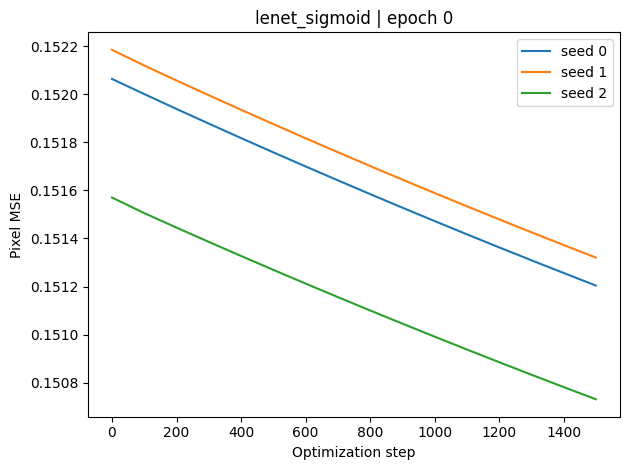

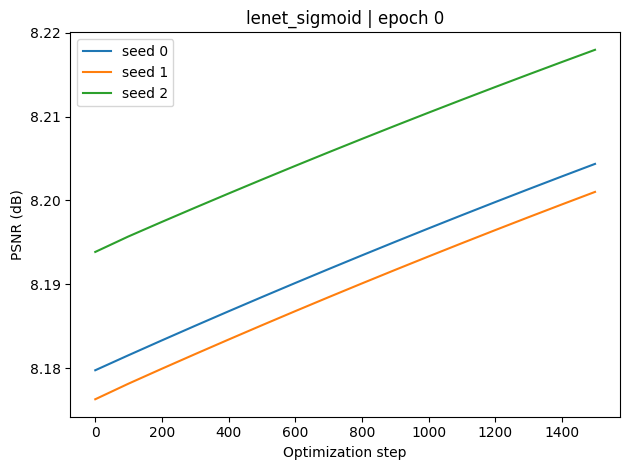

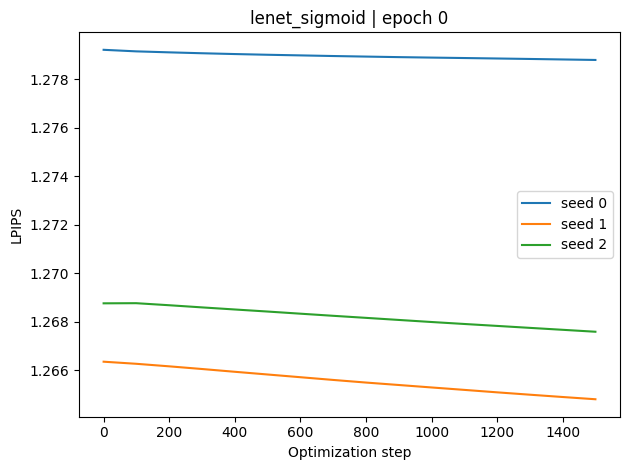

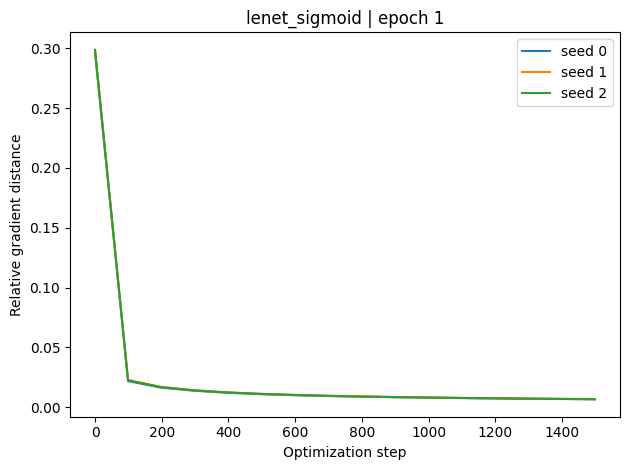

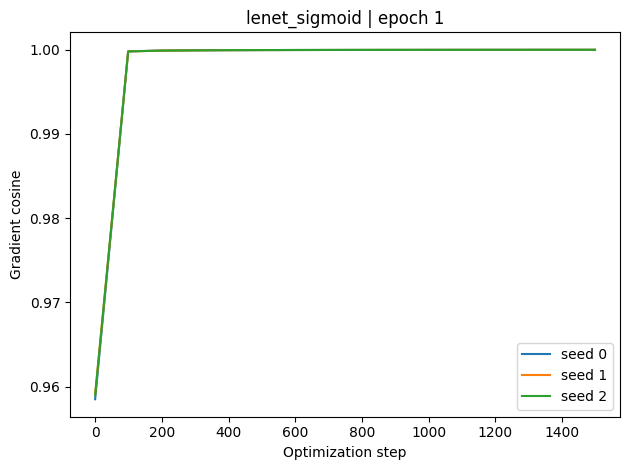

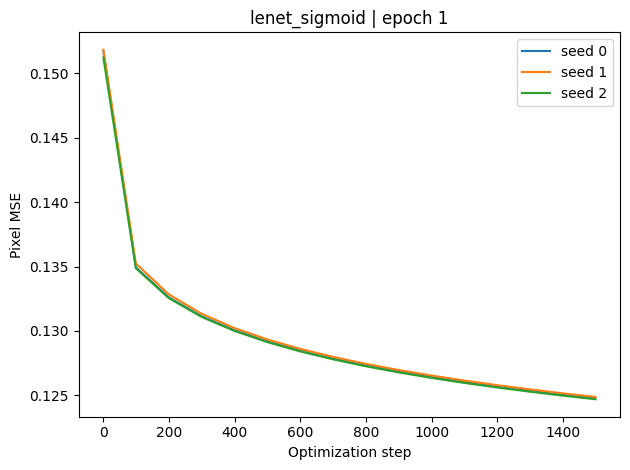

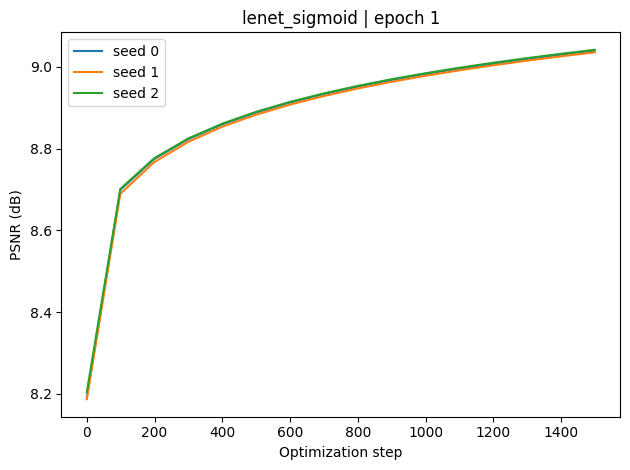

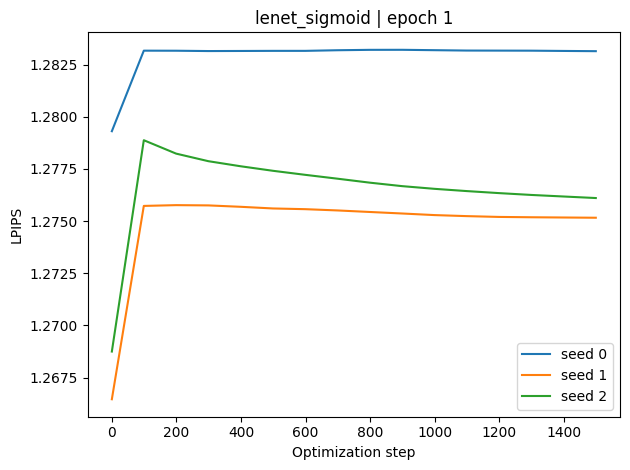

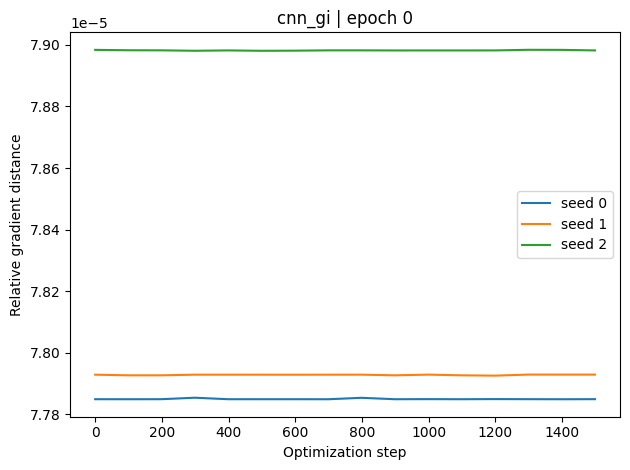

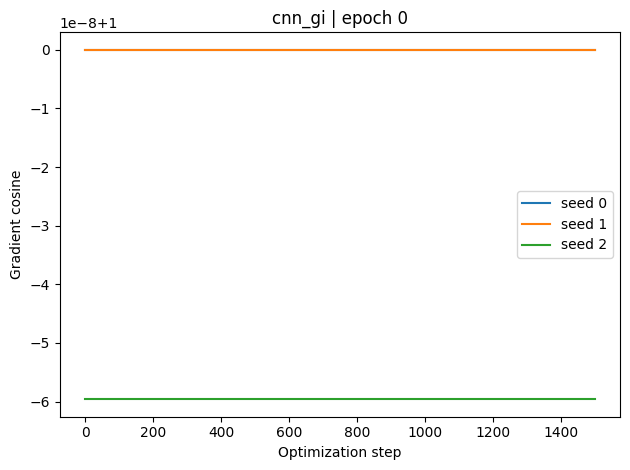

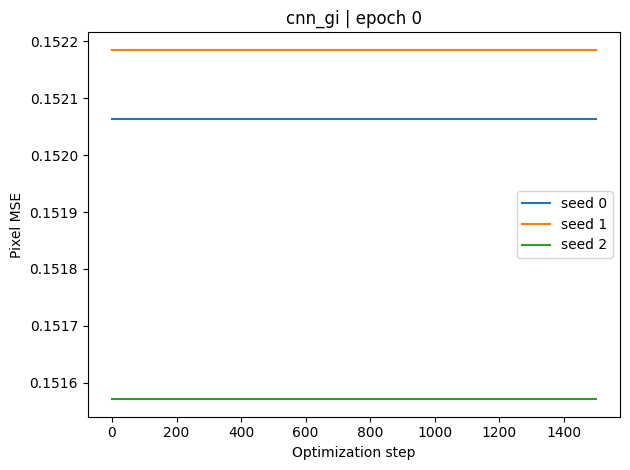

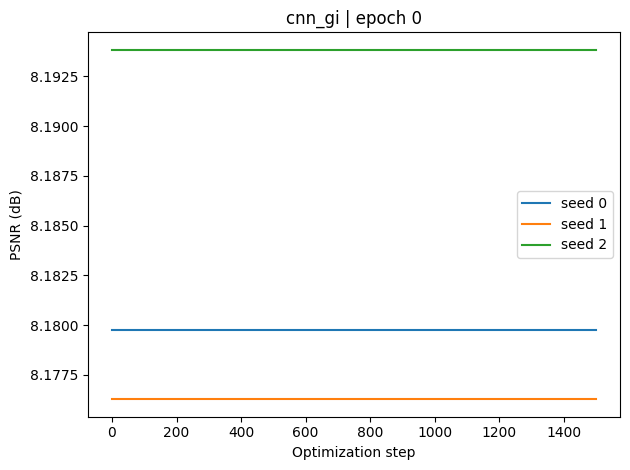

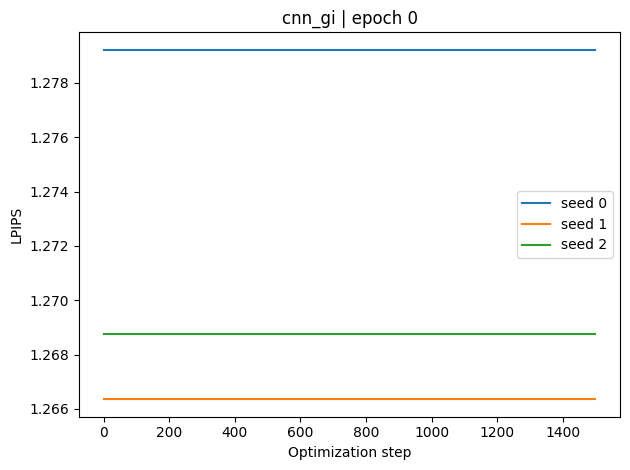

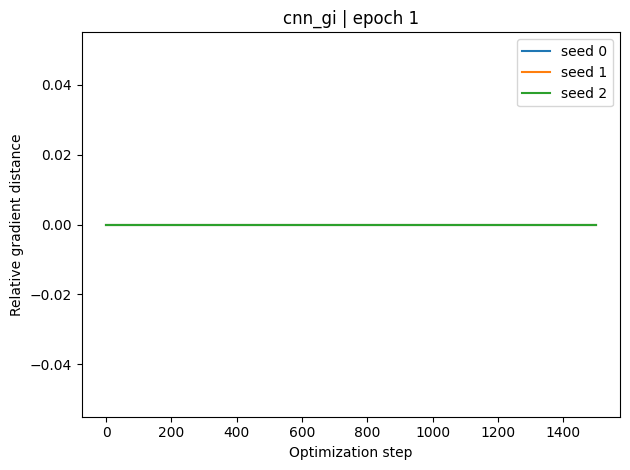

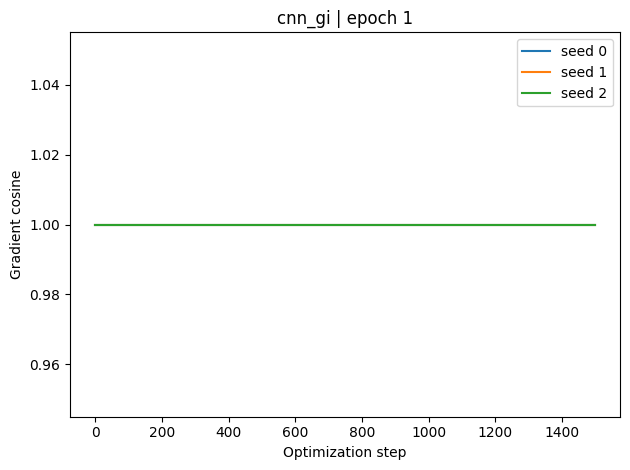

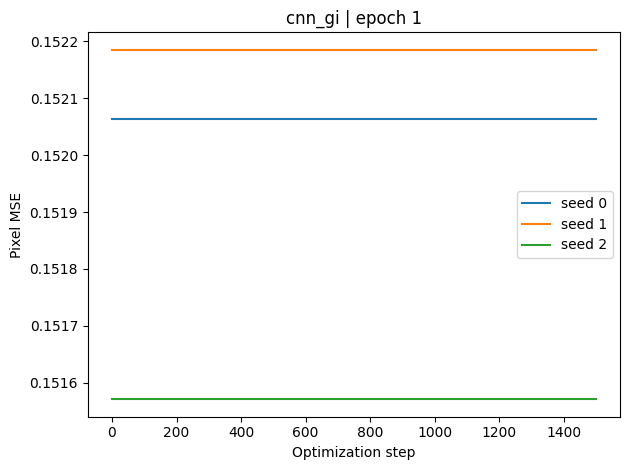

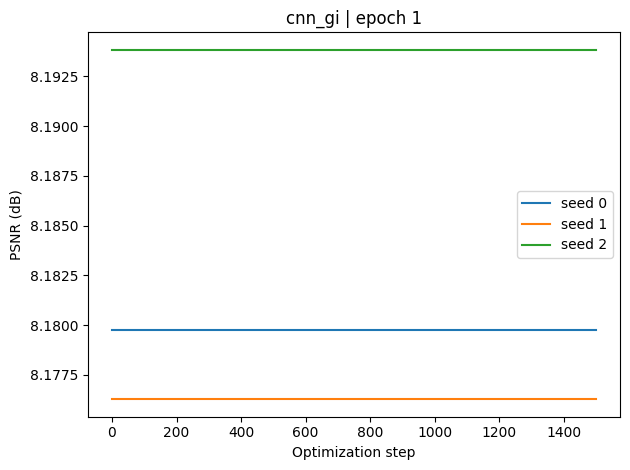

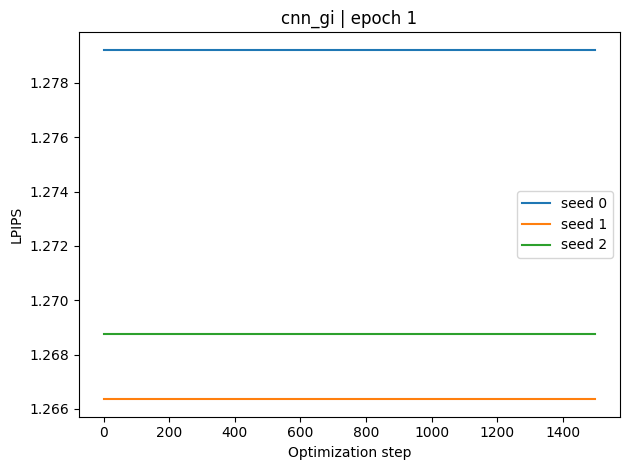

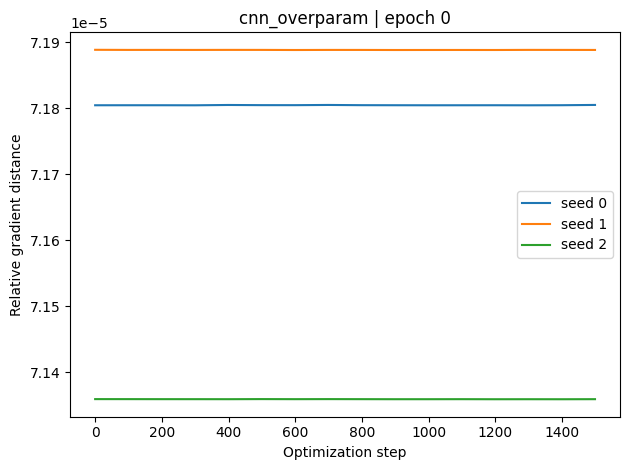

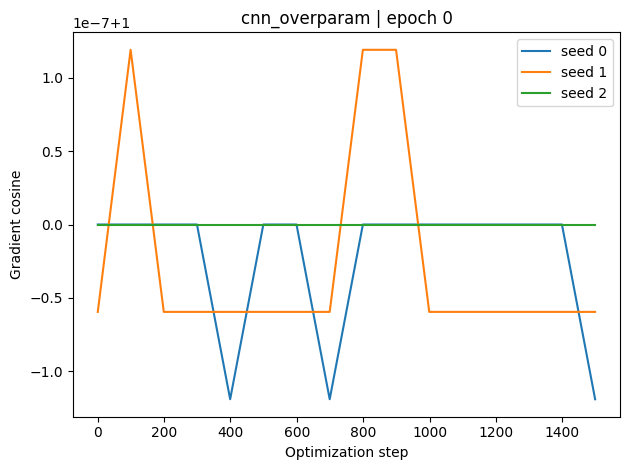

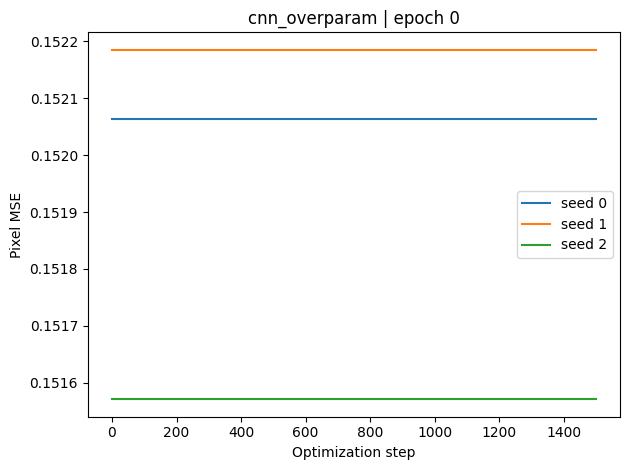

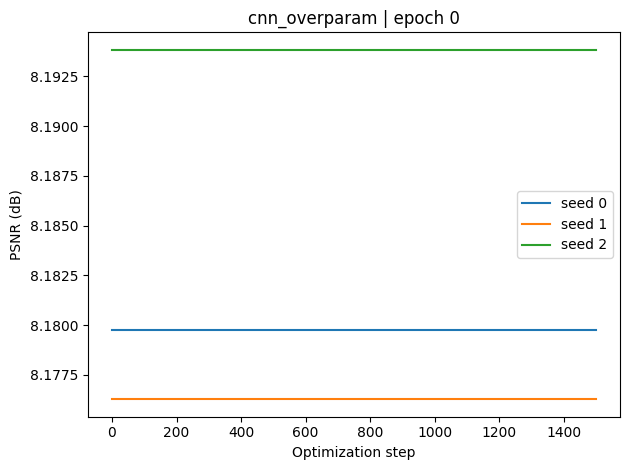

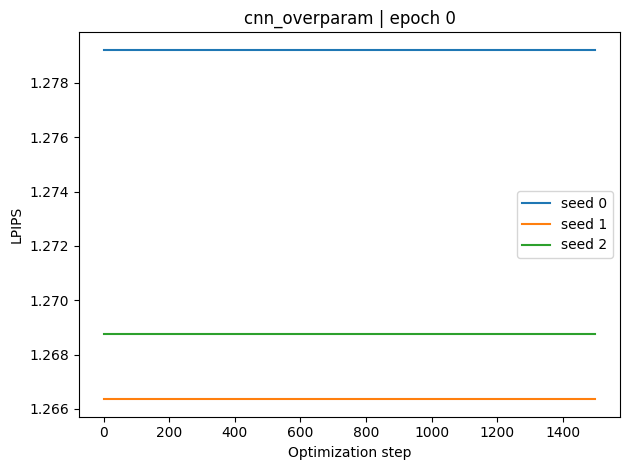

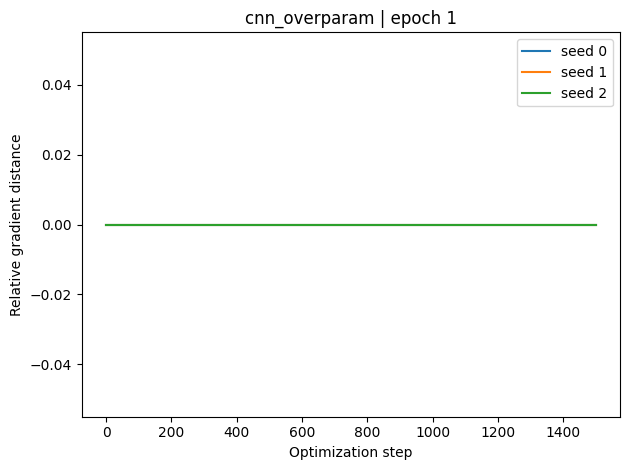

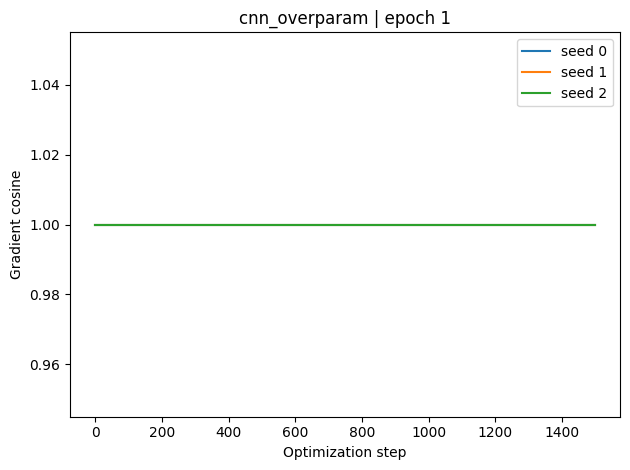

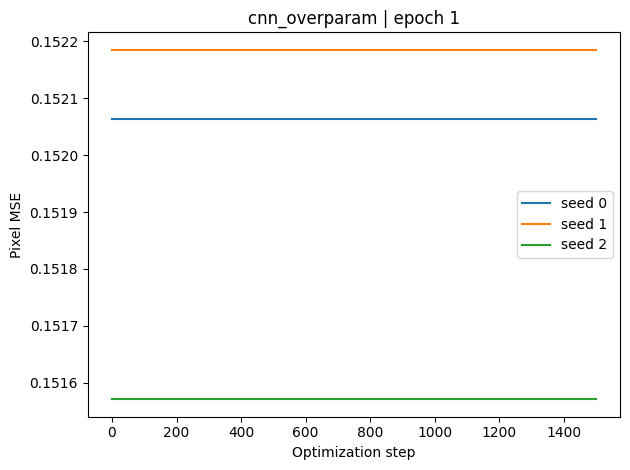

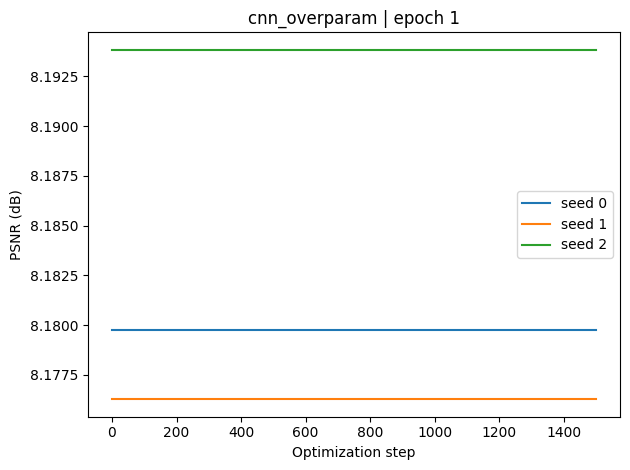

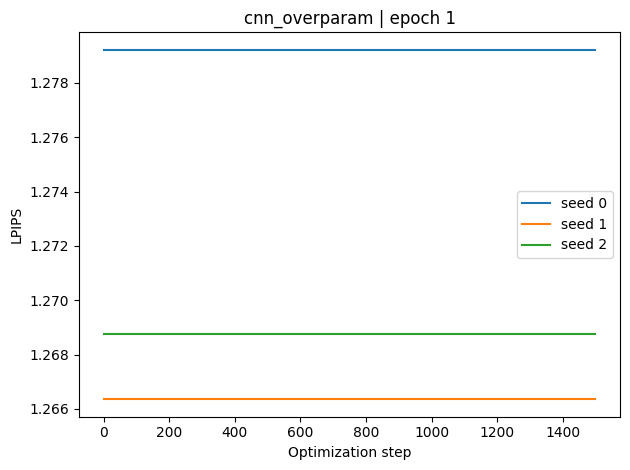

In [ ]:
# ============================================================
# CELL 21 — TRAJECTORY PLOTS
# ============================================================

import matplotlib.pyplot as plt

PLOT_DIR = RECON_DIR / "plots"
PLOT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

metrics_to_plot = [
    (
        "relative_gradient_distance",
        "Relative gradient distance",
    ),
    (
        "gradient_cosine",
        "Gradient cosine",
    ),
    (
        "mse",
        "Pixel MSE",
    ),
    (
        "psnr",
        "PSNR (dB)",
    ),
    (
        "lpips",
        "LPIPS",
    ),
]

for model_name in MODEL_FACTORIES:

    for epoch in [0, 1]:

        subset = results_df[
            (results_df["model"] == model_name)
            &
            (results_df["epoch"] == epoch)
        ]

        for metric, ylabel in metrics_to_plot:

            plt.figure()

            for seed in INVERSION_SEEDS:

                seed_data = subset[
                    subset["seed"] == seed
                ]

                # Reload trajectory from CSV
                path = (
                    TRAJ_DIR /
                    f"{model_name}"
                    f"_epoch{epoch}"
                    f"_seed{seed}.csv"
                )

                if not path.exists():
                    continue

                traj = pd.read_csv(path)

                plt.plot(
                    traj["step"],
                    traj[metric],
                    label=f"seed {seed}",
                )

            plt.xlabel("Optimization step")
            plt.ylabel(ylabel)

            plt.title(
                f"{model_name} | epoch {epoch}"
            )

            plt.legend()
            plt.tight_layout()

            path = (
                PLOT_DIR /
                f"{model_name}"
                f"_epoch{epoch}"
                f"_{metric}.png"
            )

            plt.savefig(
                path,
                dpi=150,
            )

            plt.show()
            plt.close()

# CELL 22: LAYER NORM SUMMARY

In [ ]:
# ============================================================
# CELL 22 — LAYER NORM SUMMARY
# ============================================================

layer_norm_rows = []

for (model_name, epoch), norm_df in (
    TARGET_LAYER_NORMS.items()
):

    for _, row in norm_df.iterrows():

        layer_norm_rows.append({
            "model": model_name,
            "epoch": epoch,
            "parameter": row["parameter"],
            "numel": int(row["numel"]),
            "gradient_norm": row["gradient_norm"],
        })

layer_norm_summary = pd.DataFrame(
    layer_norm_rows
)

layer_norm_path = (
    RECON_DIR /
    "target_gradient_layer_norms.csv"
)

layer_norm_summary.to_csv(
    layer_norm_path,
    index=False,
)

display(layer_norm_summary)

print(
    "Saved:",
    layer_norm_path
)

,model,epoch,parameter,numel,gradient_norm
0,mlp_small,0,fc1.weight,25165824,21.051929
1,mlp_small,0,fc1.bias,128,0.090462
2,mlp_small,0,fc2.weight,256,3.623862
3,mlp_small,0,fc2.bias,2,0.652616
4,mlp_small,0,__TOTAL__,25166210,21.371715
...,...,...,...,...,...
87,cnn_overparam,1,fc1.weight,33554432,0.000000
88,cnn_overparam,1,fc1.bias,512,0.000000
89,cnn_overparam,1,fc2.weight,1024,11.227854
90,cnn_overparam,1,fc2.bias,2,0.717321


Saved: /content/drive/MyDrive/GGSS_R_victim_architecture_comparison_for_gradient_inversion_without_diffusion/reconstruction/target_gradient_layer_norms.csv
